Load Hazard Feature Dataset

In [36]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler
import matplotlib.pyplot as plt
import seaborn as sns


df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")

df["timestamp"] = pd.to_datetime(df["timestamp"], utc=True)
df["hazard_time"] = pd.to_datetime(df["hazard_time"], utc=True)
df["t_offset"] = (df["timestamp"] - df["hazard_time"]).dt.total_seconds()

C:\Users\toufi\AppData\Local\Temp\ipykernel_10388\2542003474.py:11: DtypeWarning: Columns (0: ts_g, 1: aplicom_g, 2: address_g, 3: advdata_g, 4: geom_g, 5: source_g) have mixed types. Specify dtype option on import or set low_memory=False.
  df = pd.read_csv("HAZARD_FEATURE_DATASET.csv")


Select Features to Represent Hazards

In [37]:
features = df.groupby("hazard_id").agg({
    "gps_speed": ["mean", "min"],
    "accx_5s_mean": "mean",
    "accx_5s_min": "min",
    "grip": "mean",
    "water_layer_thickness": "mean",
    "ice_layer_thickness": "mean",
    "snow_layer_thickness": "mean",
    "black_ice_risk": "mean"
})

# Flatten column names
features.columns = ['_'.join(col).strip() for col in features.columns]
features.reset_index(inplace=True)

Standardize the Data

In [38]:

scaler = StandardScaler()
X = scaler.fit_transform(features.iloc[:, 1:])

Choose Number of Clusters (Elbow Method)

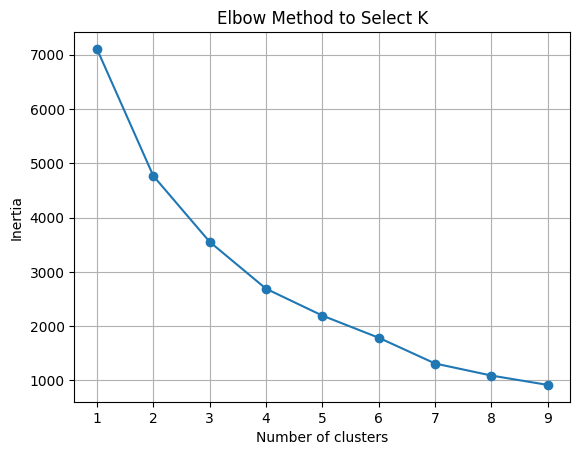

In [39]:

# 1. FIX NaN VALUES
features = features.fillna(features.median())

# 2. SCALE DATA
scaler = StandardScaler()
X = scaler.fit_transform(features.iloc[:, 1:])

# 3. ELBOW METHOD
inertias = []
for k in range(1, 10):
    km = KMeans(n_clusters=k, random_state=42, n_init=10)
    km.fit(X)
    inertias.append(km.inertia_)

plt.plot(range(1,10), inertias, marker='o')
plt.title("Elbow Method to Select K")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.grid()
plt.show()

Fit K-means Model

In [40]:
k = 4
kmeans = KMeans(n_clusters=k, random_state=42)
features["cluster"] = kmeans.fit_predict(X)

Analyze Cluster Characteristics

In [41]:
cluster_summary = features.groupby("cluster").mean()
cluster_summary

,hazard_id,gps_speed_mean,gps_speed_min,accx_5s_mean_mean,accx_5s_min_min,grip_mean,water_layer_thickness_mean,ice_layer_thickness_mean,snow_layer_thickness_mean,black_ice_risk_mean
cluster,,,,,,,,,,
0,1.907791e+07,7.337996,0.0,714.402235,690.545455,0.664588,0.441758,0.000000,0.000000,0.000000
1,2.006094e+07,5.994734,0.0,735.239103,704.680272,0.134686,0.034905,0.590672,0.010122,0.274575
2,1.879673e+07,4.706257,0.0,297.576401,-520.492308,0.630669,0.770493,0.000000,0.000000,0.000000
3,1.910518e+07,11.875483,0.0,700.000000,680.000000,0.312053,3.105926,0.050748,0.000006,0.000000


Visualize Clusters (2D PCA Projection)

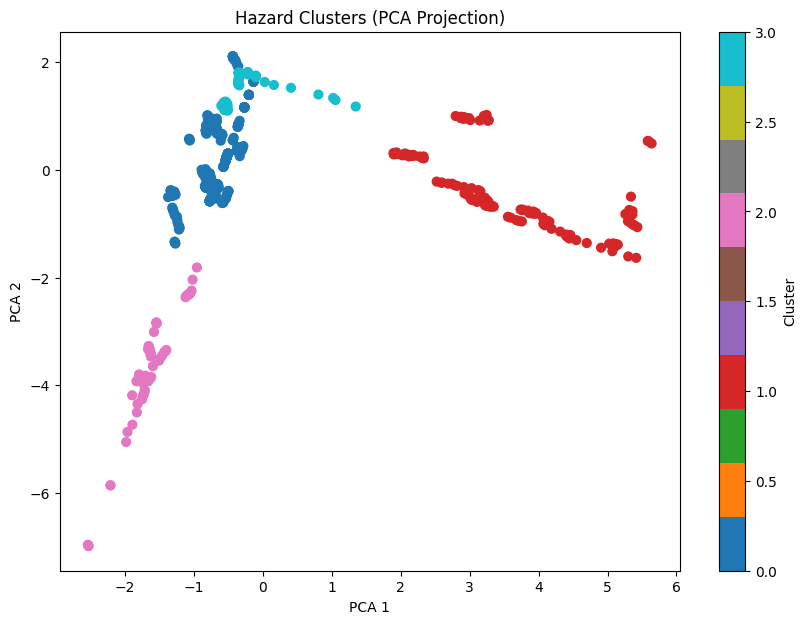

In [42]:


pca = PCA(n_components=2)
proj = pca.fit_transform(X)

plt.figure(figsize=(10,7))
plt.scatter(proj[:,0], proj[:,1], c=features["cluster"], cmap="tab10", s=40)
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.title("Hazard Clusters (PCA Projection)")
plt.colorbar(label="Cluster")
plt.show()

Visualize Cluster Counts

C:\Users\toufi\AppData\Local\Temp\ipykernel_10388\2990067187.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x=features["cluster"], palette="tab10")


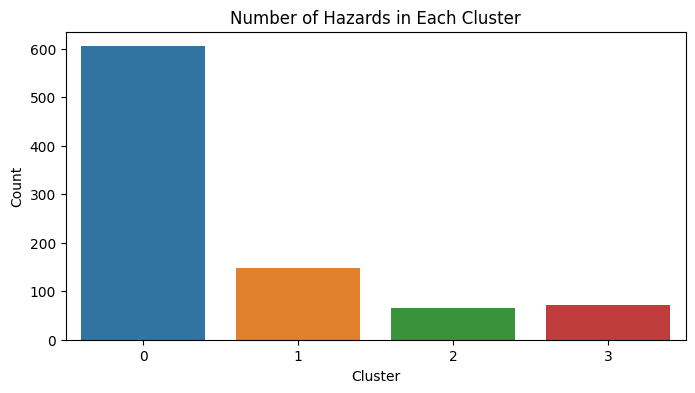

In [43]:

plt.figure(figsize=(8,4))
sns.countplot(x=features["cluster"], palette="tab10")
plt.title("Number of Hazards in Each Cluster")
plt.xlabel("Cluster")
plt.ylabel("Count")
plt.show()

STEP 9 — Visualize Cluster Profiles (Radar Chart)

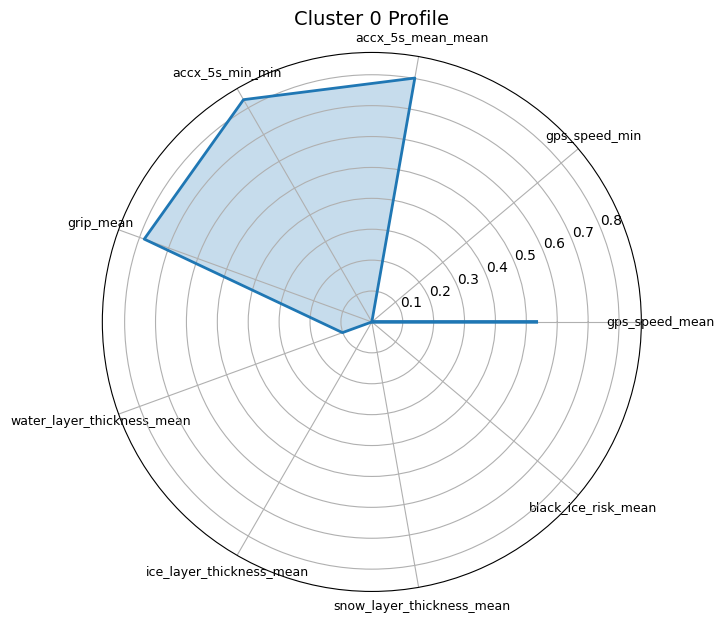

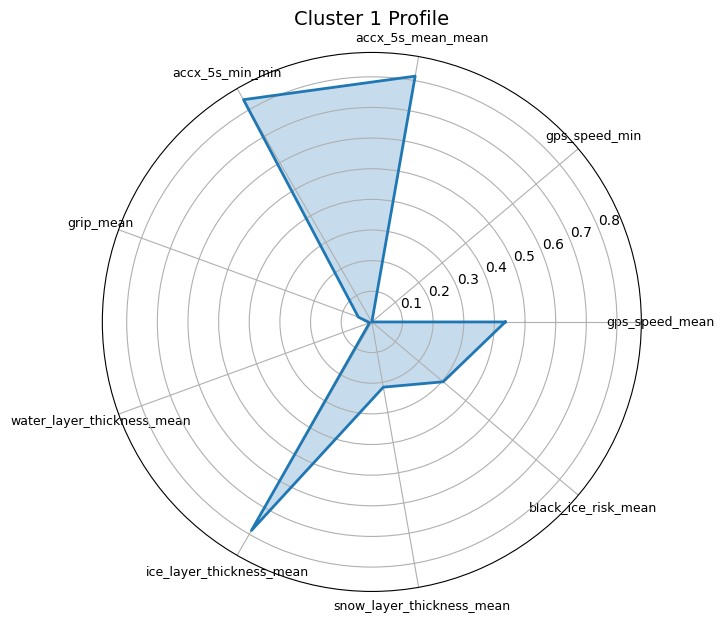

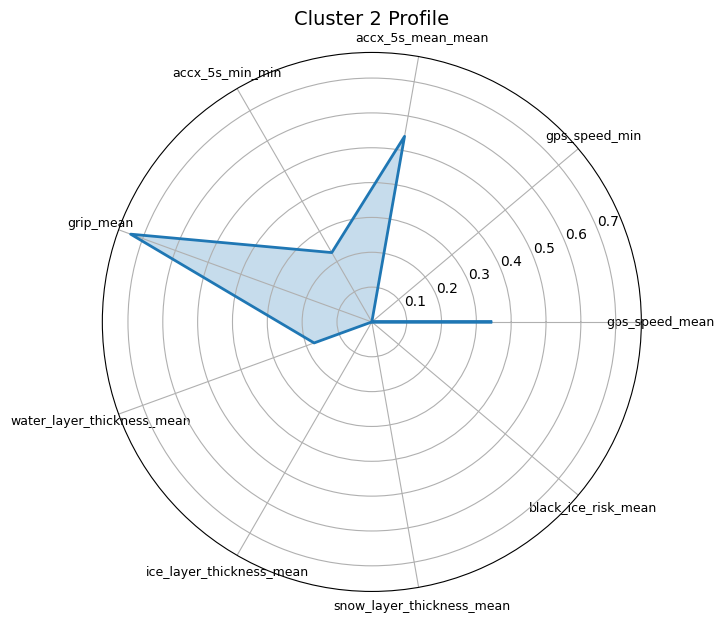

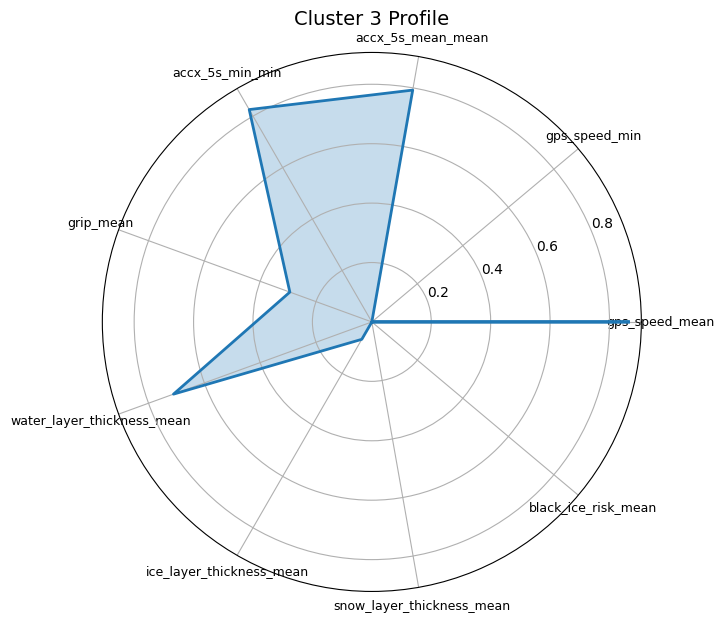

In [44]:

# ---------------------------------------
# STEP 1 — Select feature columns for radar
# ---------------------------------------

radar_features = [
    "gps_speed_mean",
    "gps_speed_min",
    "accx_5s_mean_mean",
    "accx_5s_min_min",
    "grip_mean",
    "water_layer_thickness_mean",
    "ice_layer_thickness_mean",
    "snow_layer_thickness_mean",
    "black_ice_risk_mean"
]

# "features" must already exist from K-means step
# features has one row per hazard_id + the "cluster" column

# ---------------------------------------
# STEP 2 — Handle missing data
# ---------------------------------------
features_filled = features.copy()
features_filled[radar_features] = features_filled[radar_features].fillna(features_filled[radar_features].median())

# ---------------------------------------
# STEP 3 — Normalize features (0 to 1)
# ---------------------------------------
scaler = MinMaxScaler()
norm_data = scaler.fit_transform(features_filled[radar_features])

norm_df = pd.DataFrame(norm_data, columns=radar_features)
norm_df["cluster"] = features_filled["cluster"]

# ---------------------------------------
# STEP 4 — Compute cluster centers
# ---------------------------------------
cluster_centers = norm_df.groupby("cluster").mean()

# ---------------------------------------
# STEP 5 — Radar Chart Function
# ---------------------------------------
def make_radar_chart(cluster_id, data, feature_names):
    N = len(feature_names)
    
    # Angles for radar graph
    angles = np.linspace(0, 2 * np.pi, N, endpoint=False).tolist()
    angles += angles[:1]  # close polygon
    
    # Values for the cluster
    values = data.loc[cluster_id].tolist()
    values += values[:1]  # close polygon
    
    # Plot
    fig, ax = plt.subplots(figsize=(7, 7), subplot_kw=dict(polar=True))
    
    ax.plot(angles, values, linewidth=2)
    ax.fill(angles, values, alpha=0.25)
    
    ax.set_xticks(angles[:-1])
    ax.set_xticklabels(feature_names, fontsize=9)
    
    ax.set_title(f"Cluster {cluster_id} Profile", fontsize=14, pad=20)
    ax.grid(True)
    
    plt.show()

# ---------------------------------------
# STEP 6 — Plot Radar Chart for ALL clusters
# ---------------------------------------
for cid in cluster_centers.index:
    make_radar_chart(cid, cluster_centers, radar_features)